# Investigate LMM Input Data Pipeline (ERA5 + Static)

This notebook inspects:

1. ERA5 and high-res static distributions **before preprocessing**.
2. ERA5 and high-res static distributions **after preprocessing** used by this repo.
3. How two inputs with different grid scales are forwarded into the model (UNET prior vs conditional encoder), and whether they are the same path.

It follows the code paths in:
- `src/data/components/downscaling_dataset.py`
- `src/models/ae_module.py`
- `src/models/components/ldm/conditioner.py`
- `src/models/unet_module.py`

In [ ]:
from pathlib import Path
import sys
import pickle
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import xarray as xr

# Make `src` importable whether notebook is opened from repo root or notebooks/
CWD = Path.cwd().resolve()
CANDIDATE_ROOTS = [CWD, CWD.parent]
REPO_ROOT = None
for cand in CANDIDATE_ROOTS:
    if (cand / "src").is_dir() and (cand / "configs").is_dir():
        REPO_ROOT = cand
        break
if REPO_ROOT is None:
    raise RuntimeError(
        "Could not locate repo root containing `src/` and `configs/`. "
        "Open notebook from project tree or set REPO_ROOT manually."
    )

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.components.downscaling_dataset import DownscalingDataset
from src.models.ae_module import AutoencoderKL, EncoderLRES
from src.models.components.ae import SimpleConvEncoder
from src.models.components.ldm.conditioner import AFNOConditionerNetCascade

sns.set_theme(style="whitegrid")

DATA_ROOT = (REPO_ROOT / "LDM-downscaling" / "full_Dataset").resolve()
NORM_PKL = DATA_ROOT / "normalization_data.pkl"

print(f"CWD: {CWD}")
print(f"Repo root: {REPO_ROOT}")
print(f"Data root: {DATA_ROOT}")
print(f"Metadata exists: {(DATA_ROOT / 'metadata.csv').is_file()}")
print(f"Normalization pickle exists: {NORM_PKL.is_file()}")

In [ ]:
# Match training default variable lists from configs/data/downscaling.yaml
TARGET_VARS = {
    "low_res": ["2mT", "PMSL", "U10", "V10", "dp2mT", "SST", "SNDPT", "TP", "SSRadIn", "Q850", "T850", "U850", "V850", "W850"],
    "high_res": ["2mT"],
}

STATIC_VARS = {
    "dtm_tif_file": str(DATA_ROOT / "static_var/dtm_2km_domain_trim_EPSG3035.tif"),
    "lc_tif_file": str(DATA_ROOT / "static_var/land_cover_classes_2km_domain_trim_EPSG3035.tif"),
    "lat_tif_file": str(DATA_ROOT / "static_var/lat_2km_domain_trim_EPSG3035.tif"),
}

# nn_lowres=False is the LDM/LMM training mode (return lr, hr, static separately)
ds = DownscalingDataset(
    dataset_dir=str(DATA_ROOT) + "/",
    target_vars=TARGET_VARS,
    nn_lowres=False,
    static_vars=STATIC_VARS,
    crop_size=None,
    metadata_file_name="metadata.csv",
)

print(f"Dataset length: {len(ds)}")
sample_idx = 0
lr, hr, static, ts = ds[sample_idx]
print(f"Sample shapes -> low_res: {tuple(lr.shape)}, high_res: {tuple(hr.shape)}, static: {tuple(static.shape)}")
print(f"Timestamp (ns): {ts}")

In [ ]:
def flatten_np(x):
    return np.asarray(x, dtype=np.float32).reshape(-1)

def describe_array(name, arr):
    a = flatten_np(arr)
    finite = a[np.isfinite(a)]
    out = {
        "name": name,
        "count": int(finite.size),
        "mean": float(np.mean(finite)),
        "std": float(np.std(finite)),
        "min": float(np.min(finite)),
        "p01": float(np.quantile(finite, 0.01)),
        "p50": float(np.quantile(finite, 0.50)),
        "p99": float(np.quantile(finite, 0.99)),
        "max": float(np.max(finite)),
    }
    return out

# NOTE: merged/side-by-side plotting was removed by request.
# Use strict per-variable section (Section 5) for separate histograms.

## 1) ERA5 distribution: before vs after preprocessing

For ERA5 (`low_res`) in this repo pipeline:
- The dynamic tensor is loaded from `.pt.zst` and stacked.
- `SST` NaNs are replaced with `-10`.
- No additional per-channel normalization is applied in `DownscalingDataset`.

So **"after preprocessing"** here means after dataset stacking + special-case NaN handling (not z-score in this class).

In [ ]:
# Read raw low-res dict for one timestamp directly from compressed source
meta = ds.metadata
row = meta.iloc[sample_idx]
raw_low_file = DATA_ROOT / str(row["files_path_low"]).lstrip("/")

import io, zstandard
with open(raw_low_file, "rb") as f:
    comp = f.read()
dctx = zstandard.ZstdDecompressor()
decomp = io.BytesIO(dctx.decompress(comp))
raw_payload = torch.load(decomp)
raw_low_dict = raw_payload[int(row["hour"])]  # dict: var_name -> 2D tensor

# Build stacked tensors with/without dataset preprocessing for apples-to-apples comparison
raw_low_stack = torch.stack([raw_low_dict[v].to(torch.float32) for v in TARGET_VARS["low_res"]])
proc_low = ds._stack_res_channels({"low_res": raw_low_dict}, "low_res")

print(f"Raw low_res dict keys (first 6): {list(raw_low_dict.keys())[:6]} ...")
print(f"Raw stacked low_res shape: {tuple(raw_low_stack.shape)}")
print(f"Processed low_res shape: {tuple(proc_low.shape)}")

era5_channel = TARGET_VARS["low_res"].index("2mT")
raw_era5 = raw_low_stack[era5_channel].numpy()
proc_era5 = proc_low[era5_channel].numpy()

print(pd.DataFrame([
    describe_array("ERA5 2mT raw", raw_era5),
    describe_array("ERA5 2mT processed", proc_era5),
]))

print("Merged side-by-side plot removed. See Section 5 for strict separate histograms per variable.")

## 2) High-res static distribution: before vs after preprocessing

For static rasters (`dtm`, `lat`, and one-hot land-cover channels), `DownscalingDataset`:
- loads `.tif` rasters,
- expands land-cover bands into channels,
- applies z-score normalization to non-landcover static fields via:

`(tensor - tensor.mean()) / (tensor.std() + 1e-10)`

This section compares raw raster values against normalized tensor values.

In [ ]:
# Compare raw vs normalized for dtm and lat
raw_dtm = xr.open_dataset(STATIC_VARS["dtm_tif_file"], engine="rasterio")["band_data"][0].values
raw_lat = xr.open_dataset(STATIC_VARS["lat_tif_file"], engine="rasterio")["band_data"][0].values

proc_dtm = ds.static_data["dtm_tif_file"].numpy()
proc_lat = ds.static_data["lat_tif_file"].numpy()

stats_df = pd.DataFrame([
    describe_array("DTM raw", raw_dtm),
    describe_array("DTM normalized", proc_dtm),
    describe_array("LAT raw", raw_lat),
    describe_array("LAT normalized", proc_lat),
])
stats_df

In [ ]:
print("Merged side-by-side static plots removed. See Section 5 for strict separate histograms per channel.")

# Example for one land-cover one-hot channel (categorical, not z-score normalized here)
lc_key = [k for k in ds.static_data.keys() if "lc_tif_file_cat_" in k][0]
print(f"Inspecting land-cover channel: {lc_key}")
proc_lc = ds.static_data[lc_key].numpy()
print(pd.DataFrame([describe_array(f"{lc_key} (processed)", proc_lc)]))

plt.figure(figsize=(6, 4))
plt.hist(flatten_np(proc_lc), bins=3, density=True, color="C0", alpha=0.8)
plt.title(f"{lc_key} value distribution")
plt.grid(alpha=0.2)
plt.show()

In [ ]:
# Optional: inspect dataset-wide normalization stats used in the project
if NORM_PKL.is_file():
    with open(NORM_PKL, "rb") as f:
        norm_values = pickle.load(f)

    era5_stats = pd.DataFrame({
        "mean": norm_values["ERA5"]["mean"],
        "std": norm_values["ERA5"]["std"],
    }).sort_index()

    cmcc_stats = pd.DataFrame({
        "mean": norm_values["CMCC"]["mean"],
        "std": norm_values["CMCC"]["std"],
    }).sort_index()

    print("ERA5 normalization stats (from normalization_data.pkl):")
    display(era5_stats)
    print("CMCC normalization stats (from normalization_data.pkl):")
    display(cmcc_stats)
else:
    print("normalization_data.pkl not found; skip this cell.")

## 3) How low-res ERA5 and high-res static enter UNET vs conditional encoder

They are **not the same path**.

- **UNET prior path** (`nn_lr_and_merge_with_static`):
  1. nearest-neighbor upsample low-res ERA5 by `x8` to high-res grid,
  2. concatenate with static channels,
  3. pass the merged high-res tensor to UNET.

- **Conditioner path** (`AFNOConditionerNetCascade`):
  1. process static and low-res in **two separate branches**,
  2. encode/project each branch,
  3. fuse branch features at matched feature-grid scale,
  4. output a context cascade for MFUNet.

So both use ERA5 + static, but **fusion timing and representation are different**.

In [26]:
# Build a batch of size 1 from dataset sample
lr_b = lr.unsqueeze(0)       # (1, C_lr, H_lr, W_lr)
static_b = static.unsqueeze(0)  # (1, C_static, H_hr, W_hr)

# UNET prior input path: upsample lr to high-res and concatenate static
lr_up = torch.repeat_interleave(torch.repeat_interleave(lr_b, 8, dim=2), 8, dim=3)
unet_input = torch.cat([lr_up, static_b], dim=1)

print("UNET prior path:")
print(f"  low_res original: {tuple(lr_b.shape)}")
print(f"  low_res upsampled x8: {tuple(lr_up.shape)}")
print(f"  static: {tuple(static_b.shape)}")
print(f"  concatenated UNET input: {tuple(unet_input.shape)}")

# Conditioner path: two branches (static branch + low-res branch)
# Use architecture consistent with configs/model/lmm.yaml
static_encoder = AutoencoderKL(
    encoder=SimpleConvEncoder(in_dim=static_b.shape[1], levels=3, ch_mult=3),
    decoder=torch.nn.Identity(),
)
lowres_encoder = EncoderLRES(encoded_channels=lr_b.shape[1] * 2)

context_encoder = AFNOConditionerNetCascade(
    autoencoder=[static_encoder, lowres_encoder],
    cascade_depth=3,
    embed_dim=[128, 24],
    analysis_depth=[4, 4],
    afno_fusion=True,
    input_size_ratios=(1, 1),
    embed_dim_out=256,
    train_autoenc=True,
)

with torch.no_grad():
    context_cascade = context_encoder([(static_b, [0]), (lr_b, [0])])

print("\nConditioner path output cascade:")
for k, v in context_cascade.items():
    print(f"  feature grid {k} -> {tuple(v.shape)}")


Conditioner path output cascade:
  feature grid (84, 72) -> (1, 256, 84, 72)
  feature grid (42, 36) -> (1, 512, 42, 36)
  feature grid (21, 18) -> (1, 1024, 21, 18)


## Quick interpretation checklist

- If `ERA5 raw` and `ERA5 processed` look identical for `2mT`, that is expected in this dataset class.
- If static normalized histograms are centered around ~0 with std ~1 (`dtm`, `lat`), preprocessing is behaving as coded.
- The shape trace should confirm:
  - UNET gets one merged **high-res** tensor,
  - conditioner builds a **multi-scale context cascade** from two branches.

This answers **"is it the same?"**: **No, not the same computational path.**

In [27]:
# Optional: inspect all low-res channels quickly
for i, var in enumerate(TARGET_VARS["low_res"]):
    arr = proc_low[i].numpy()
    d = describe_array(var, arr)
    print(f"{var:8s} mean={d['mean']:+.4f} std={d['std']:.4f} min={d['min']:+.4f} max={d['max']:+.4f}")

2mT      mean=-1.4350 std=0.9702 min=-4.9766 max=-0.3184
PMSL     mean=+1.1088 std=0.3040 min=+0.2173 max=+1.7969
U10      mean=+0.1863 std=0.6315 min=-1.3477 max=+2.4551
V10      mean=-0.6898 std=0.7553 min=-2.7441 max=+0.7412
dp2mT    mean=-1.5876 std=0.7692 min=-4.7578 max=-0.3113
SST      mean=-5.1409 std=4.4693 min=-10.0000 max=-0.5244
SNDPT    mean=+0.2317 std=1.2857 min=-0.1591 max=+8.5078
TP       mean=-0.1133 std=0.4690 min=-0.2479 max=+3.6113
SSRadIn  mean=-0.7080 std=0.0000 min=-0.7080 max=-0.7080
Q850     mean=-1.2056 std=0.4185 min=-1.9277 max=-0.1550
T850     mean=-1.7627 std=0.2954 min=-2.6211 max=-1.1572
U850     mean=-0.1427 std=0.5824 min=-2.3945 max=+1.1895
V850     mean=-0.7640 std=0.5743 min=-2.4648 max=+0.4651
W850     mean=+0.0887 std=0.8747 min=-3.7656 max=+5.9570


## 4) Per-variable distributions (ERA5 + static): before vs after normalization

This section computes distributions for **each variable**:

- ERA5 low-res channels: raw values vs z-score normalized values using `normalization_data.pkl` (`ERA5` stats).
- High-res static channels:
  - `dtm_tif_file` and `lat_tif_file`: raw raster vs dataset-normalized raster.
  - `lc_tif_file_cat_*`: one-hot categorical bands (kept as-is in current pipeline).

To reduce noise, this aggregates pixels from many random timestamps.

In [28]:
# Config for stable per-variable histograms
N_SAMPLES = 64      # increase to 128+ for smoother estimates
RANDOM_SEED = 42
MAX_PIXELS_PER_VAR = 300_000

rng = np.random.default_rng(RANDOM_SEED)
all_indices = np.arange(len(ds))
sel_indices = rng.choice(all_indices, size=min(N_SAMPLES, len(all_indices)), replace=False)

if not NORM_PKL.is_file():
    raise FileNotFoundError(f"Missing normalization stats: {NORM_PKL}")

with open(NORM_PKL, "rb") as f:
    norm_values = pickle.load(f)

print(f"Using {len(sel_indices)} random timestamps for distribution estimation")
print(f"ERA5 vars: {len(TARGET_VARS['low_res'])}")
print(f"Static channels in dataset: {len(ds.static_data)}")

Using 64 random timestamps for distribution estimation
ERA5 vars: 14
Static channels in dataset: 18


In [29]:
import io, zstandard

def _load_raw_low_dict(idx):
    row = ds.metadata.iloc[int(idx)]
    raw_low_file = DATA_ROOT / str(row["files_path_low"]).lstrip("/")
    with open(raw_low_file, "rb") as f:
        comp = f.read()
    dctx = zstandard.ZstdDecompressor()
    decomp = io.BytesIO(dctx.decompress(comp))
    raw_payload = torch.load(decomp)
    return raw_payload[int(row["hour"])]

def _sample_pixels(arr, max_pixels=MAX_PIXELS_PER_VAR, seed=0):
    a = np.asarray(arr, dtype=np.float32).reshape(-1)
    a = a[np.isfinite(a)]
    if a.size <= max_pixels:
        return a
    rr = np.random.default_rng(seed)
    pick = rr.choice(a.size, size=max_pixels, replace=False)
    return a[pick]

def _summarize_pair(before, after, name):
    b = _sample_pixels(before, seed=123)
    a = _sample_pixels(after, seed=456)
    return {
        "variable": name,
        "before_mean": float(np.mean(b)),
        "before_std": float(np.std(b)),
        "after_mean": float(np.mean(a)),
        "after_std": float(np.std(a)),
        "before_p01": float(np.quantile(b, 0.01)),
        "before_p50": float(np.quantile(b, 0.50)),
        "before_p99": float(np.quantile(b, 0.99)),
        "after_p01": float(np.quantile(a, 0.01)),
        "after_p50": float(np.quantile(a, 0.50)),
        "after_p99": float(np.quantile(a, 0.99)),
    }

# NOTE: overlay plotting removed by request.
# Use `plot_hist_single` in Section 5 for separate raw/normalized histograms.

In [30]:
# ERA5: collect raw and normalized pixels per variable across selected timestamps
era5_raw = {v: [] for v in TARGET_VARS["low_res"]}
era5_norm = {v: [] for v in TARGET_VARS["low_res"]}

for idx in sel_indices:
    raw_low_dict = _load_raw_low_dict(int(idx))
    for v in TARGET_VARS["low_res"]:
        arr = raw_low_dict[v].numpy()
        if v == "SST":
            arr = np.nan_to_num(arr, nan=-10.0)
        era5_raw[v].append(arr.reshape(-1))

        mean_v = float(norm_values["ERA5"]["mean"][v])
        std_v = float(norm_values["ERA5"]["std"][v])
        arr_n = (arr - mean_v) / (std_v + 1e-12)
        era5_norm[v].append(arr_n.reshape(-1))

for v in TARGET_VARS["low_res"]:
    era5_raw[v] = np.concatenate(era5_raw[v], axis=0)
    era5_norm[v] = np.concatenate(era5_norm[v], axis=0)

era5_summary = pd.DataFrame([
    _summarize_pair(era5_raw[v], era5_norm[v], v) for v in TARGET_VARS["low_res"]
]).sort_values("variable")

era5_summary

/tmp/ipykernel_1477110/1343207912.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  raw_payload = torch.load(decomp)
/tmp/ipykernel_1477110/1205510988.py:15: RuntimeWarni

,variable,before_mean,before_std,after_mean,after_std,before_p01,before_p50,before_p99,after_p01,after_p50,after_p99
0,2mT,0.177212,0.862315,-36.509174,0.108272,-2.294922,0.258789,1.792969,-36.812500,-36.500000,-36.312500
1,PMSL,0.064612,0.869485,-149.606277,0.001280,-2.138672,0.015297,2.435547,-149.609512,-149.606339,-149.602783
9,Q850,0.166688,0.964019,73.789513,439.048340,-1.773447,0.087402,2.476562,-811.000000,37.437500,1126.000000
6,SNDPT,-0.037798,0.913223,-1.289201,28.103483,-0.159058,-0.159058,4.757812,-5.031250,-5.031250,147.625000
8,SSRadIn,0.173232,1.180954,-0.707939,0.000001,-0.708008,-0.690674,2.826172,-0.707940,-0.707940,-0.707936
5,SST,-4.505836,5.092063,-65.779800,1.131466,-10.000000,-1.141602,1.778320,-67.000000,-65.062500,-64.375000
10,T850,0.217431,0.850160,-39.440174,0.120603,-1.713877,0.197998,2.070312,-39.718750,-39.437500,-39.187500
7,TP,-0.016464,1.016257,-49.026890,2585.615967,-0.247925,-0.247925,4.574219,-653.500000,-653.500000,12048.000000
2,U10,-0.190115,0.913561,-0.207924,0.259242,-2.710938,-0.189697,2.437500,-0.923828,-0.208008,0.538086
11,U850,-0.175859,0.887848,-0.428101,0.159405,-2.326172,-0.246460,2.218750,-0.813477,-0.440674,0.002457


In [31]:
# Disabled: merged/overlay ERA5 plots removed by request.
print("Section 4 overlay plots disabled. Use Section 5 for strict separate raw/normalized histograms.")

Section 4 overlay plots disabled. Use Section 5 for strict separate raw/normalized histograms.


In [32]:
# Static: per-channel before vs after normalization
# dtm/lat are normalized in dataset; lc one-hot channels are left as categorical bands.

static_summary_rows = []

for key in ds.static_data.keys():
    proc = ds.static_data[key].numpy()

    if key == "dtm_tif_file":
        raw = xr.open_dataset(STATIC_VARS["dtm_tif_file"], engine="rasterio")["band_data"][0].values
        mode = "z-score normalized in dataset"
    elif key == "lat_tif_file":
        raw = xr.open_dataset(STATIC_VARS["lat_tif_file"], engine="rasterio")["band_data"][0].values
        mode = "z-score normalized in dataset"
    elif key.startswith("lc_tif_file_cat_"):
        cat_idx = int(key.split("_cat_")[-1]) - 1
        raw_lc = xr.open_dataset(STATIC_VARS["lc_tif_file"], engine="rasterio")["band_data"].values
        raw = raw_lc[cat_idx]
        mode = "categorical one-hot (not z-score normalized)"
    else:
        # Fallback for any future static channel naming
        raw = proc
        mode = "unknown (treated as identity)"

    static_summary_rows.append({
        **_summarize_pair(raw, proc, key),
        "normalization_mode": mode,
    })

static_summary = pd.DataFrame(static_summary_rows).sort_values("variable")
static_summary

,variable,before_mean,before_std,after_mean,after_std,before_p01,before_p50,before_p99,after_p01,after_p50,after_p99,normalization_mode
0,dtm_tif_file,2.934702e+02,520.161194,0.000054,0.999635,0.0,0.0,2.378656e+03,-0.563935,-0.563935,4.013722,z-score normalized in dataset
17,lat_tif_file,2.026099e+06,387928.812500,-0.000108,0.999749,1367000.0,2025000.0,2.685000e+06,-1.698543,-0.002577,1.698544,z-score normalized in dataset
1,lc_tif_file_cat_1,3.243000e-02,0.177139,0.032407,0.177078,0.0,0.0,1.000000e+00,0.000000,0.000000,1.000000,categorical one-hot (not z-score normalized)
10,lc_tif_file_cat_10,9.777334e-02,0.297008,0.098640,0.298178,0.0,0.0,1.000000e+00,0.000000,0.000000,1.000000,categorical one-hot (not z-score normalized)
11,lc_tif_file_cat_11,1.354667e-02,0.115599,0.013500,0.115403,0.0,0.0,1.000000e+00,0.000000,0.000000,1.000000,categorical one-hot (not z-score normalized)
12,lc_tif_file_cat_12,1.285667e-02,0.112656,0.012990,0.113231,0.0,0.0,1.000000e+00,0.000000,0.000000,1.000000,categorical one-hot (not z-score normalized)
13,lc_tif_file_cat_13,1.666667e-05,0.004082,0.000020,0.004472,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,categorical one-hot (not z-score normalized)
14,lc_tif_file_cat_14,1.833333e-04,0.013539,0.000173,0.013164,0.0,0.0,0.000000e+00,0.000000,0.000000,0.000000,categorical one-hot (not z-score normalized)
15,lc_tif_file_cat_15,4.963333e-02,0.217186,0.049437,0.216778,0.0,0.0,1.000000e+00,0.000000,0.000000,1.000000,categorical one-hot (not z-score normalized)
16,lc_tif_file_cat_16,5.376133e-01,0.498583,0.537713,0.498576,0.0,1.0,1.000000e+00,0.000000,1.000000,1.000000,categorical one-hot (not z-score normalized)


In [33]:
# Disabled: merged/overlay static plots removed by request.
print("Section 4 overlay static plots disabled. Use Section 5 for strict separate raw/normalized histograms.")

Section 4 overlay static plots disabled. Use Section 5 for strict separate raw/normalized histograms.


## 5) Per-variable output (2 tables + 1 horizontal merged figure)

For each ERA5 variable and static channel:

- Table A: raw distribution stats
- Table B: normalized/processed distribution stats
- One horizontal figure with 2 subplots:
  - left = raw histogram
  - right = normalized/processed histogram

In [34]:
def distribution_table_single(values, variable_name, version_name):
    x = _sample_pixels(values, seed=111)
    return pd.DataFrame([
        {
            "variable": variable_name,
            "version": version_name,
            "count": int(x.size),
            "mean": float(np.mean(x)),
            "std": float(np.std(x)),
            "min": float(np.min(x)),
            "p01": float(np.quantile(x, 0.01)),
            "p05": float(np.quantile(x, 0.05)),
            "p25": float(np.quantile(x, 0.25)),
            "p50": float(np.quantile(x, 0.50)),
            "p75": float(np.quantile(x, 0.75)),
            "p95": float(np.quantile(x, 0.95)),
            "p99": float(np.quantile(x, 0.99)),
            "max": float(np.max(x)),
        }
    ])


def plot_hist_pair_horizontal(raw_values, norm_values, variable_name, raw_label="raw", norm_label="normalized", bins=120):
    x_raw = _sample_pixels(raw_values, seed=222)
    x_norm = _sample_pixels(norm_values, seed=333)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

    axes[0].hist(x_raw, bins=bins, density=True, color="C0", alpha=0.85)
    axes[0].set_title(f"{variable_name} - {raw_label}")
    axes[0].set_xlabel("value")
    axes[0].set_ylabel("density")
    axes[0].grid(alpha=0.2)

    axes[1].hist(x_norm, bins=bins, density=True, color="C1", alpha=0.85)
    axes[1].set_title(f"{variable_name} - {norm_label}")
    axes[1].set_xlabel("value")
    axes[1].set_ylabel("density")
    axes[1].grid(alpha=0.2)

    plt.show()

ERA5 variable: 2mT
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,2mT,raw,300000,0.17696,0.863363,-5.117188,-2.302734,-1.473633,-0.279053,0.258789,0.796387,1.333984,1.792969,2.869141


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,2mT,normalized (ERA5 stats),300000,-36.509182,0.108236,-37.1875,-36.8125,-36.71875,-36.5625,-36.5,-36.4375,-36.375,-36.3125,-36.1875


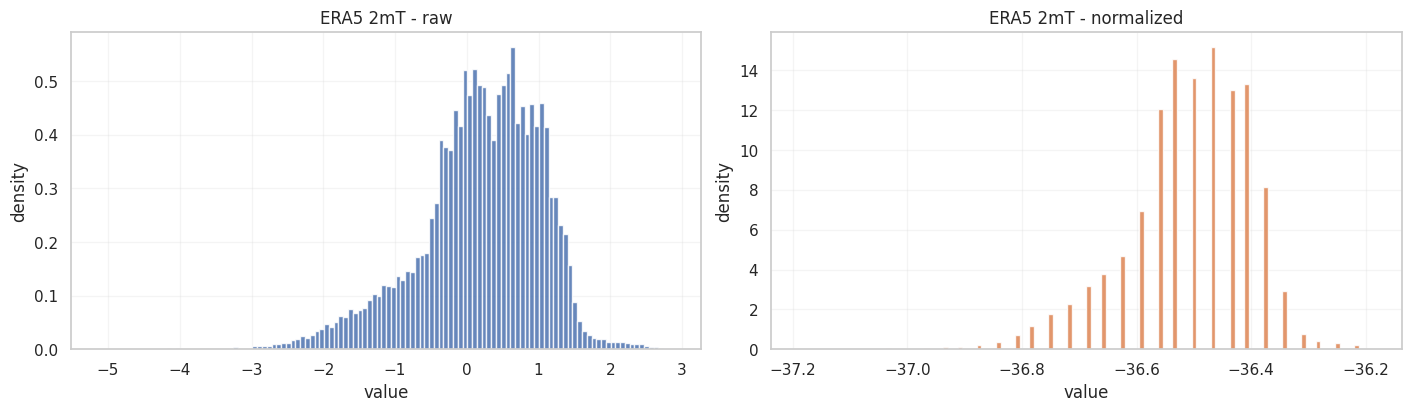

ERA5 variable: PMSL
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,PMSL,raw,300000,0.065237,0.869434,-3.275391,-2.138672,-1.285156,-0.432861,0.014931,0.505859,1.80957,2.4375,2.802734


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,PMSL,normalized (ERA5 stats),300000,-149.606293,0.00128,-149.611191,-149.609512,-149.608246,-149.606995,-149.606339,-149.605621,-149.603699,-149.602783,-149.602234


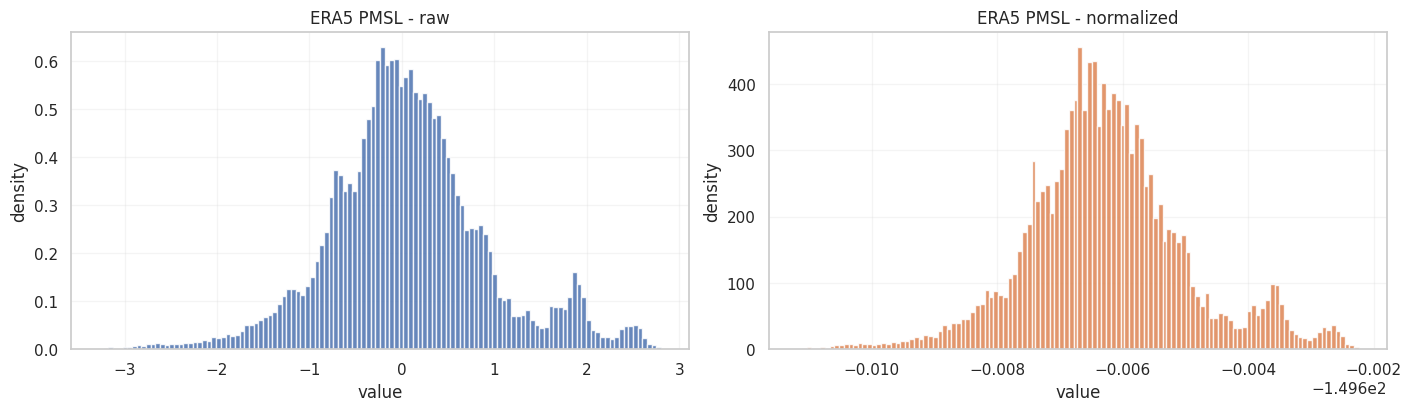

ERA5 variable: U10
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,U10,raw,300000,-0.189641,0.912992,-5.300781,-2.710938,-1.734375,-0.615723,-0.189697,0.236206,1.336914,2.4375,4.320312


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,U10,normalized (ERA5 stats),300000,-0.208038,0.259265,-1.65918,-0.923828,-0.646484,-0.328857,-0.208008,-0.087097,0.225464,0.538086,1.072266


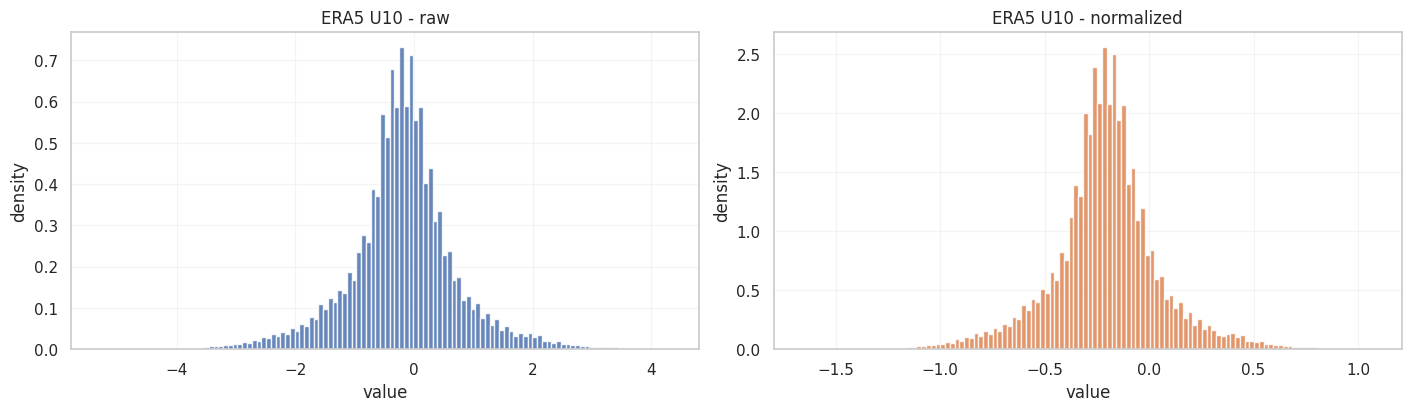

ERA5 variable: V10
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,V10,raw,300000,0.123945,0.943179,-4.476562,-2.427734,-1.419922,-0.359924,0.099854,0.594238,1.748047,2.681641,4.421875


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,V10,normalized (ERA5 stats),300000,0.154441,0.276263,-1.193359,-0.592773,-0.297852,0.012709,0.147339,0.292236,0.630371,0.903809,1.413086


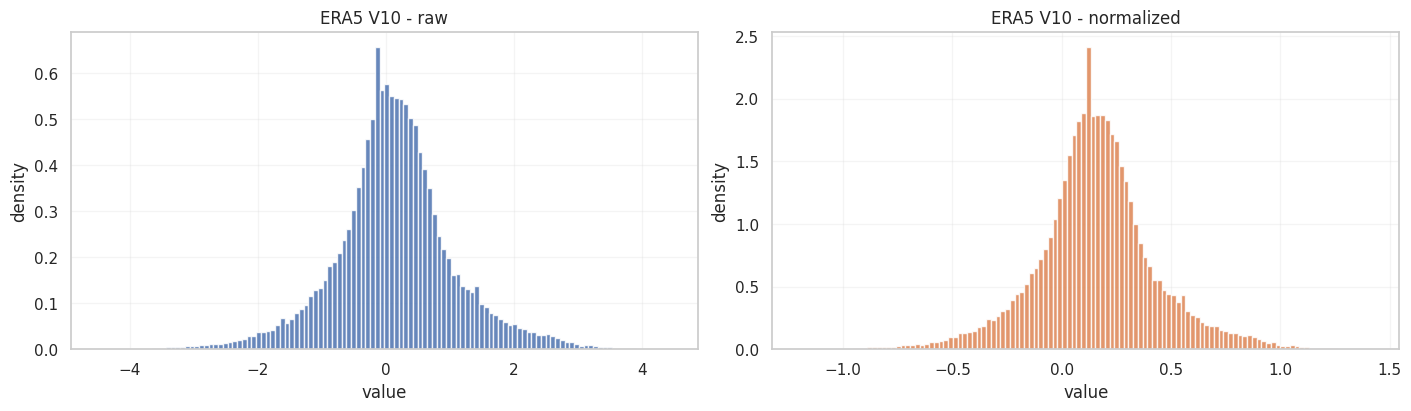

ERA5 variable: dp2mT
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,dp2mT,raw,300000,0.215151,0.856342,-5.527344,-2.279297,-1.310547,-0.282715,0.288818,0.827637,1.449219,1.697266,1.979492


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,dp2mT,normalized (ERA5 stats),300000,-37.593578,0.114528,-38.34375,-37.90625,-37.78125,-37.65625,-37.59375,-37.53125,-37.40625,-37.375,-37.34375


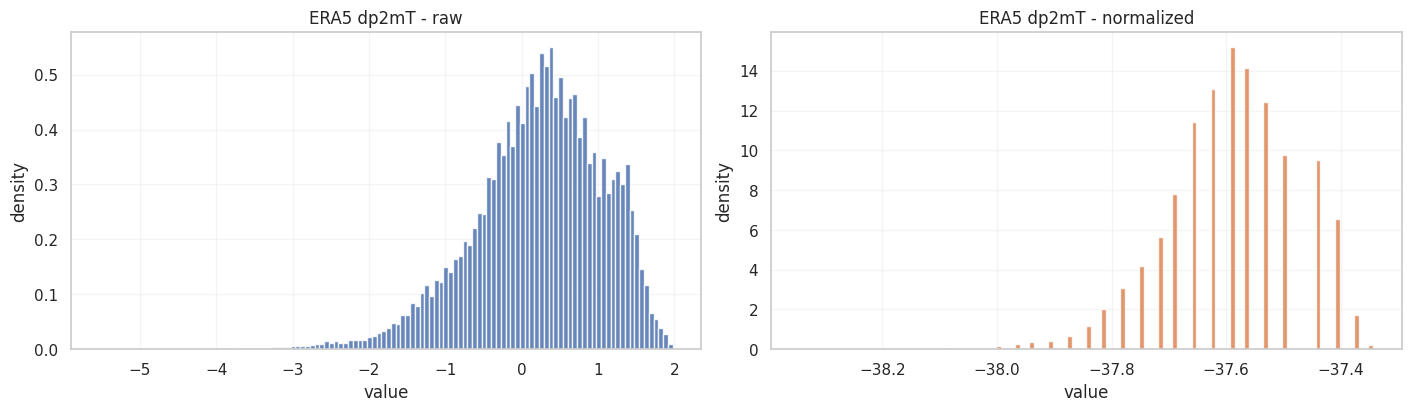

ERA5 variable: SST
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SST,raw,300000,-4.506636,5.093544,-10.0,-10.0,-10.0,-10.0,-1.147949,0.366943,1.376953,1.77832,2.082031


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SST,normalized (ERA5 stats),300000,-65.779526,1.131653,-67.0,-67.0,-67.0,-67.0,-65.0625,-64.75,-64.4375,-64.375,-64.3125


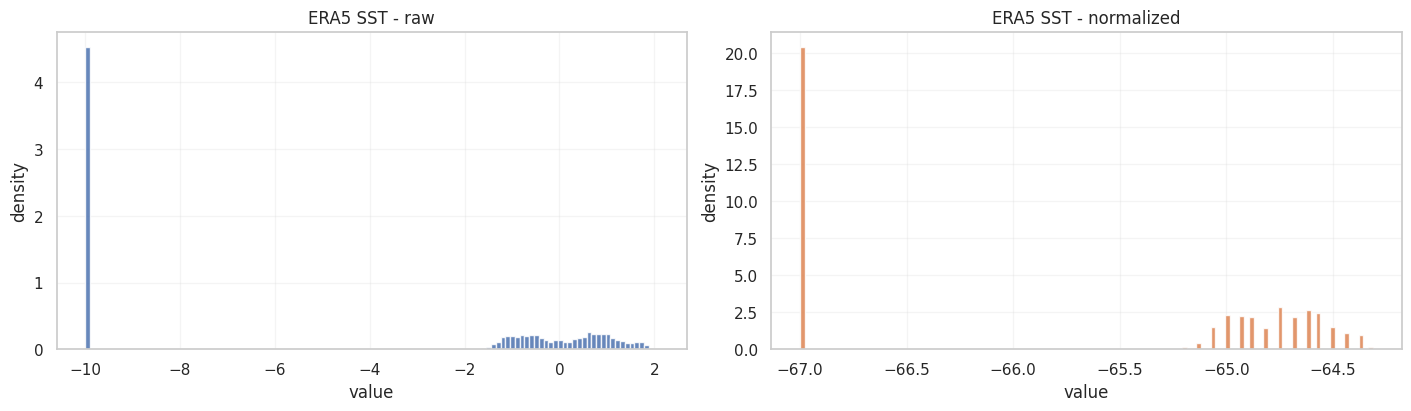

ERA5 variable: SNDPT
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SNDPT,raw,300000,-0.037586,0.915698,-0.159058,-0.159058,-0.159058,-0.159058,-0.159058,-0.159058,-0.144043,4.820352,16.6875


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SNDPT,normalized (ERA5 stats),300000,-1.311477,28.03957,-5.03125,-5.03125,-5.03125,-5.03125,-5.03125,-5.03125,-4.570312,147.50125,511.0


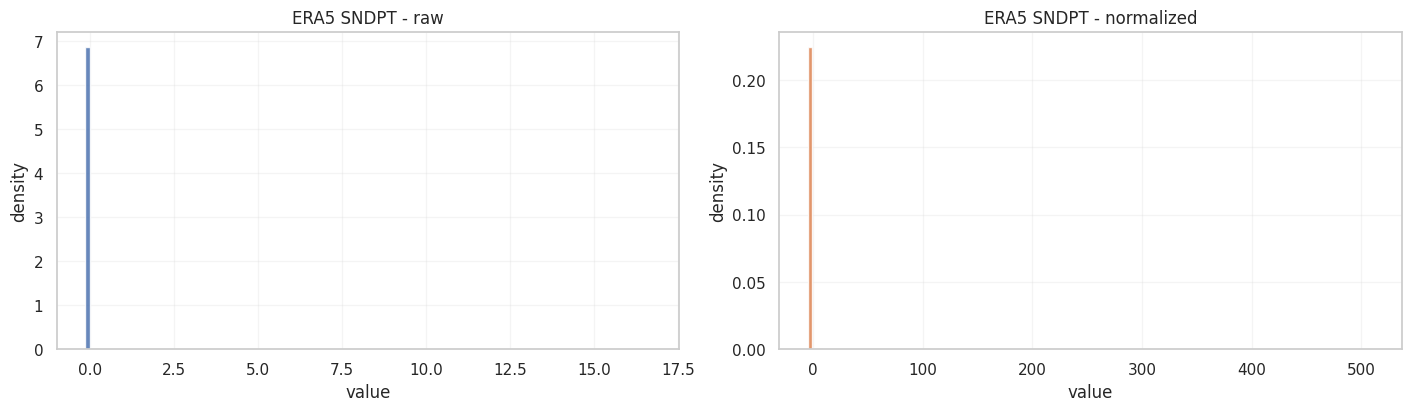

ERA5 variable: TP
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,TP,raw,300000,-0.015659,1.025879,-0.247925,-0.247925,-0.247925,-0.247925,-0.247925,-0.247925,1.038086,4.574219,45.90625


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,TP,normalized (ERA5 stats),300000,-48.500065,2601.476318,-653.5,-653.5,-653.5,-653.5,-653.5,-653.5,2734.0,12048.0,64992.0


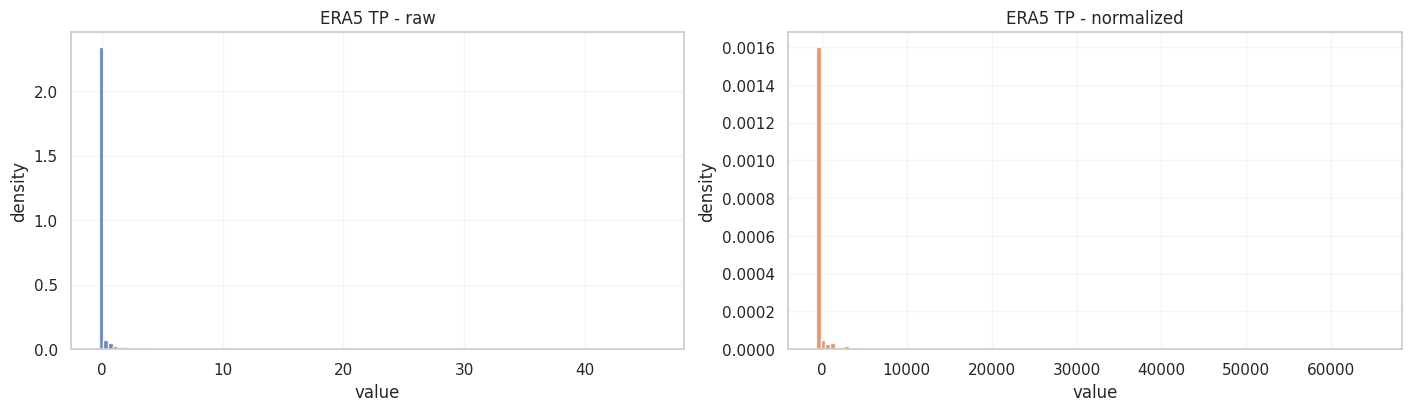

ERA5 variable: SSRadIn
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SSRadIn,raw,300000,0.171339,1.179767,-0.708008,-0.708008,-0.708008,-0.708008,-0.690918,0.907715,2.603516,2.826191,3.138672


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,SSRadIn,normalized (ERA5 stats),300000,-0.707939,0.000001,-0.70794,-0.70794,-0.70794,-0.70794,-0.70794,-0.707938,-0.707936,-0.707936,-0.707936


/home/chuongtnd/git-repo/Physically-conditioned-latent-diffusion-model-for-temperature/.venv/lib/python3.13/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


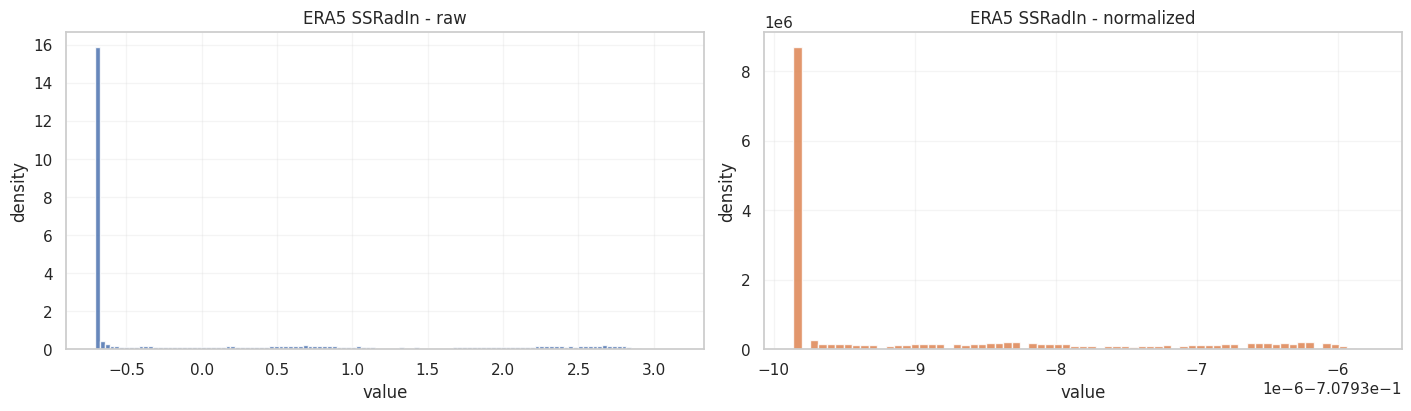

ERA5 variable: Q850
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,Q850,raw,300000,0.166827,0.963551,-2.099609,-1.773438,-1.323242,-0.530273,0.08783,0.833496,1.874023,2.472656,3.757812


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,Q850,normalized (ERA5 stats),300000,73.815948,438.933899,-958.0,-810.0,-605.0,-243.75,37.84375,377.5,851.5,1125.0,1710.0


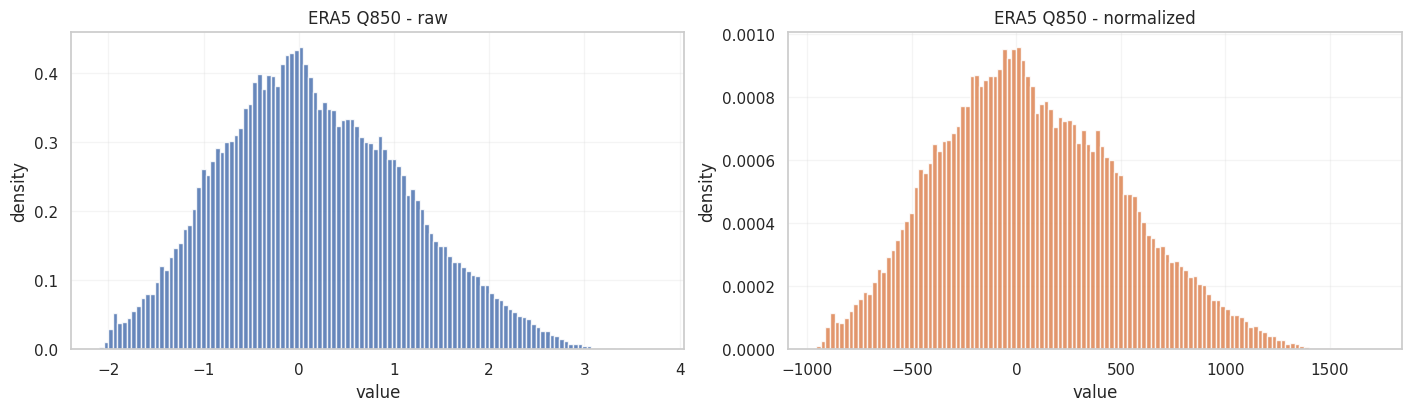

ERA5 variable: T850
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,T850,raw,300000,0.217213,0.851274,-3.130859,-1.720703,-1.132812,-0.354248,0.196899,0.851074,1.572266,2.074219,2.544922


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,T850,normalized (ERA5 stats),300000,-39.440105,0.120694,-39.9375,-39.71875,-39.65625,-39.5,-39.4375,-39.375,-39.25,-39.1875,-39.125


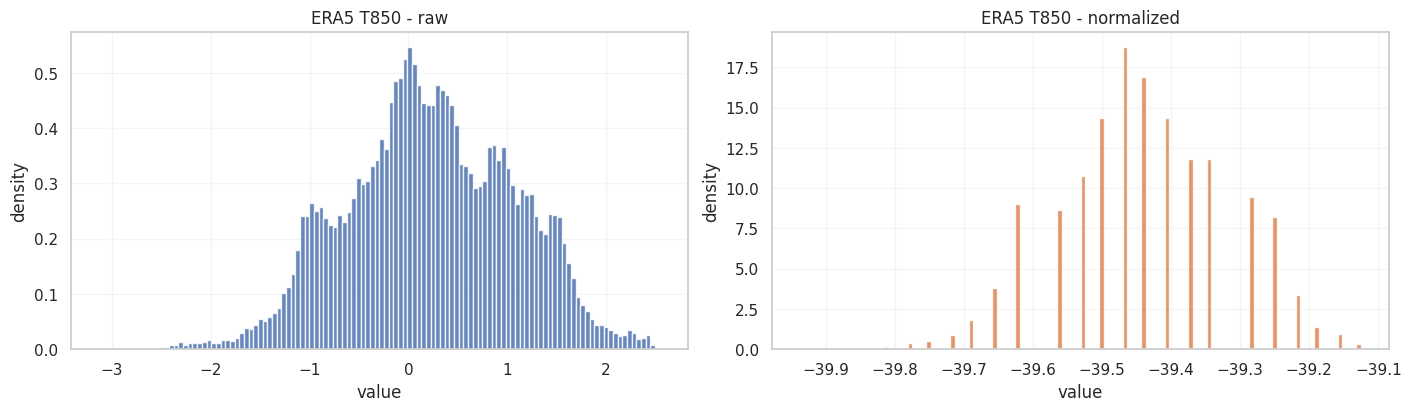

ERA5 variable: U850
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,U850,raw,300000,-0.175621,0.888829,-4.761719,-2.328125,-1.563477,-0.694336,-0.24646,0.336182,1.348633,2.228516,4.351562


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,U850,normalized (ERA5 stats),300000,-0.428042,0.159677,-1.251953,-0.814941,-0.677246,-0.521484,-0.440674,-0.336182,-0.154175,0.00386,0.385254


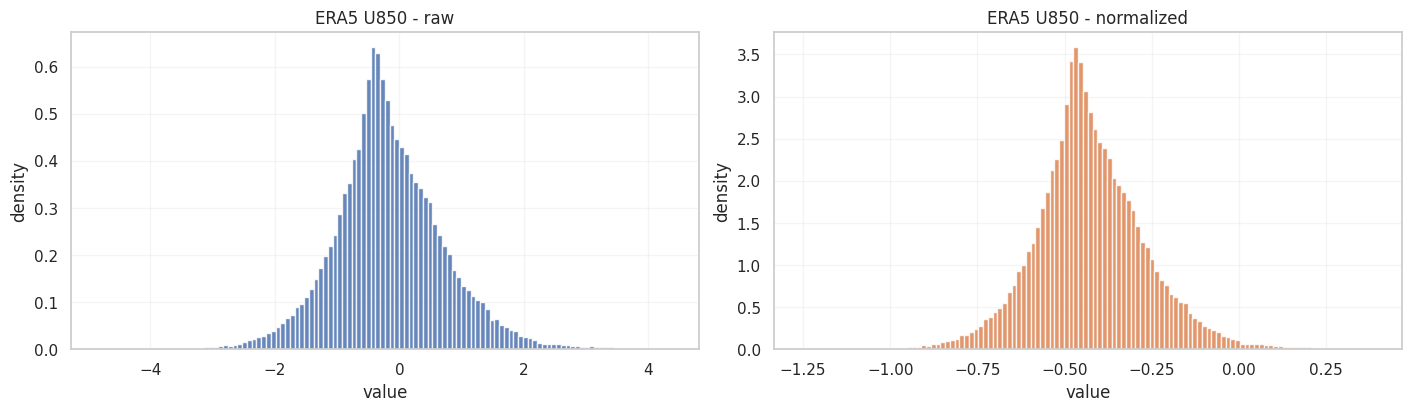

ERA5 variable: V850
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,V850,raw,300000,0.184494,0.958854,-4.097656,-2.037109,-1.258789,-0.368164,0.109375,0.618652,2.039062,2.984375,4.910156


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,V850,normalized (ERA5 stats),300000,0.130955,0.169873,-0.627441,-0.262695,-0.124756,0.033051,0.117676,0.208008,0.459473,0.626953,0.968262


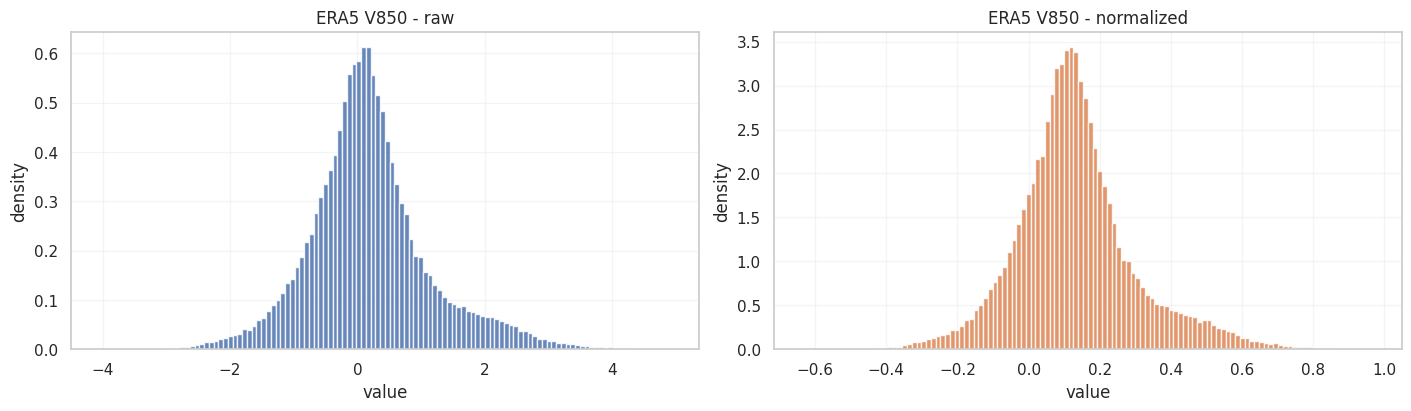

ERA5 variable: W850
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,W850,raw,300000,-0.023186,0.892935,-19.296875,-2.726562,-1.375,-0.348389,0.024979,0.341797,1.12793,2.572266,12.4375


Normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,W850,normalized (ERA5 stats),300000,-0.077693,2.24661,-48.5625,-6.878906,-3.478516,-0.895508,0.04361,0.84082,2.818359,6.453125,31.265625


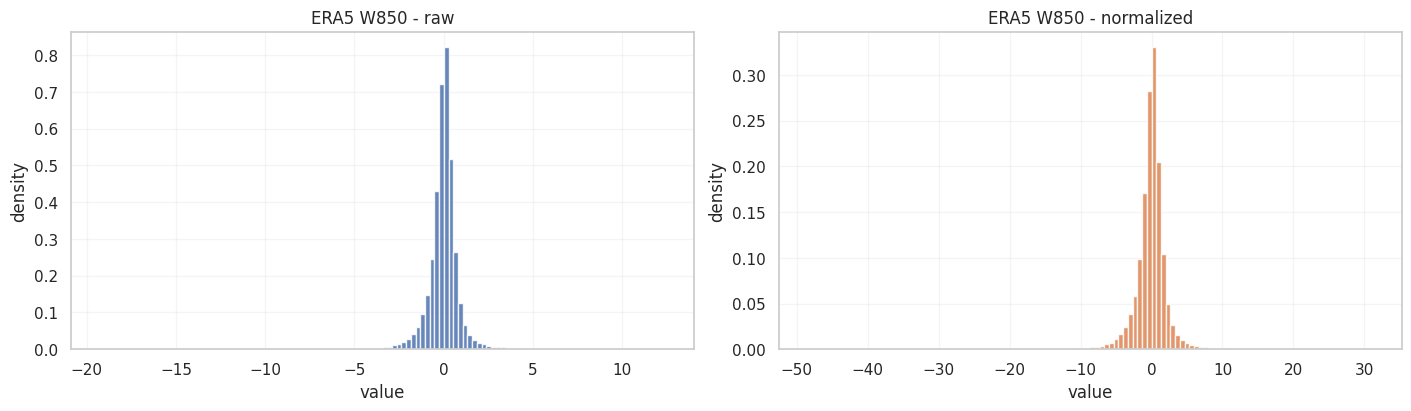

In [35]:
# ERA5: for EACH variable print 2 tables + 1 horizontal merged figure (raw | normalized)
for v in TARGET_VARS["low_res"]:
    print("=" * 90)
    print(f"ERA5 variable: {v}")

    print("Raw distribution table:")
    display(distribution_table_single(era5_raw[v], variable_name=v, version_name="raw"))

    print("Normalized distribution table:")
    display(distribution_table_single(era5_norm[v], variable_name=v, version_name="normalized (ERA5 stats)"))

    plot_hist_pair_horizontal(
        era5_raw[v],
        era5_norm[v],
        variable_name=f"ERA5 {v}",
        raw_label="raw",
        norm_label="normalized",
        bins=120,
    )

Static channel: dtm_tif_file
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,dtm_tif_file,raw,300000,293.349243,519.667786,-10.488952,0.0,0.0,0.0,0.0,383.095436,1428.952124,2376.615334,4060.724609


normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,dtm_tif_file,normalized,300000,-0.000106,0.998822,-0.584095,-0.563935,-0.563935,-0.563935,-0.563935,0.17239,2.182568,4.004015,7.240941


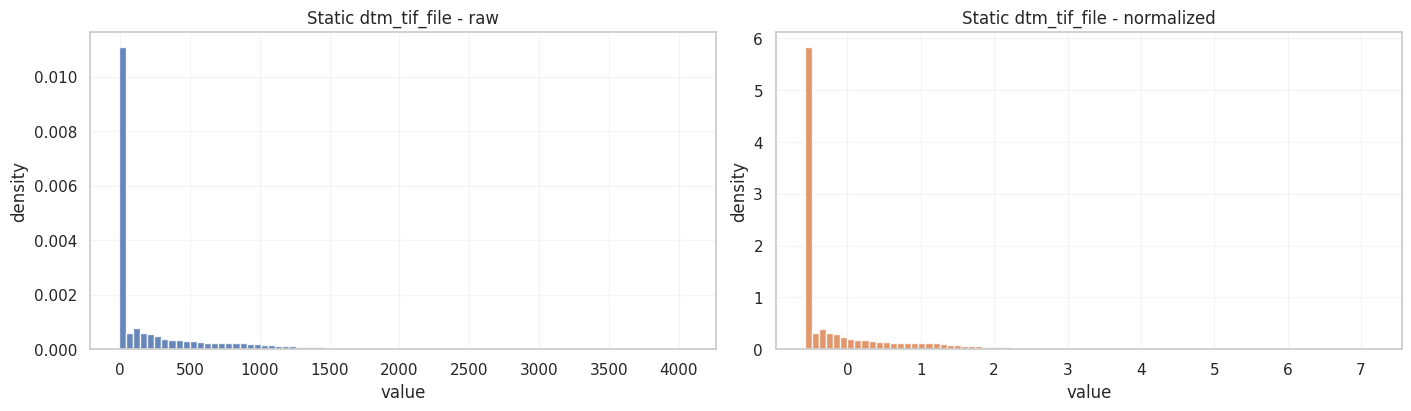

Static channel: lc_tif_file_cat_1
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_1,raw,300000,0.032443,0.177174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_1,processed (categorical band),300000,0.032443,0.177174,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


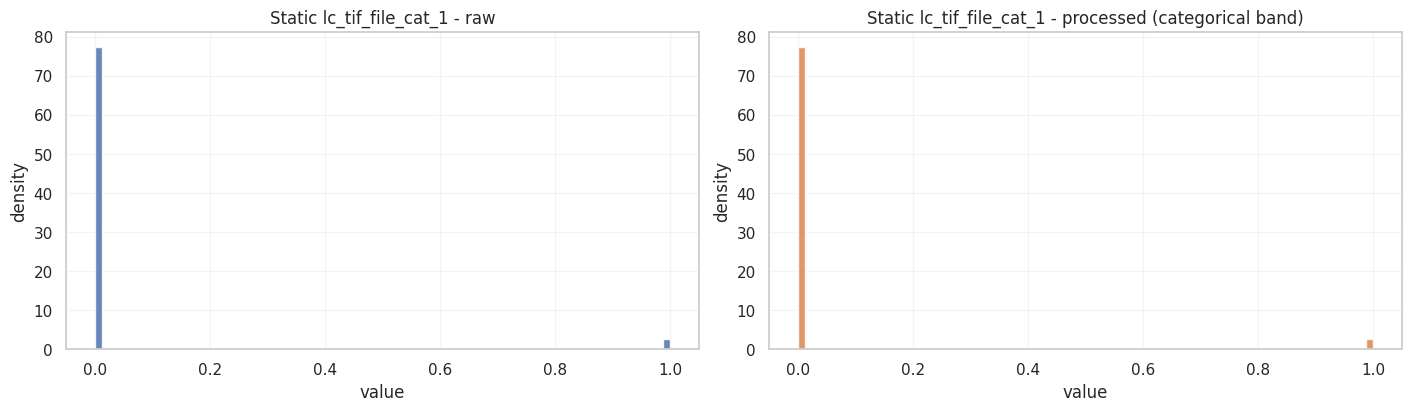

Static channel: lc_tif_file_cat_2
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_2,raw,300000,0.05228,0.222591,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_2,processed (categorical band),300000,0.05228,0.222591,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


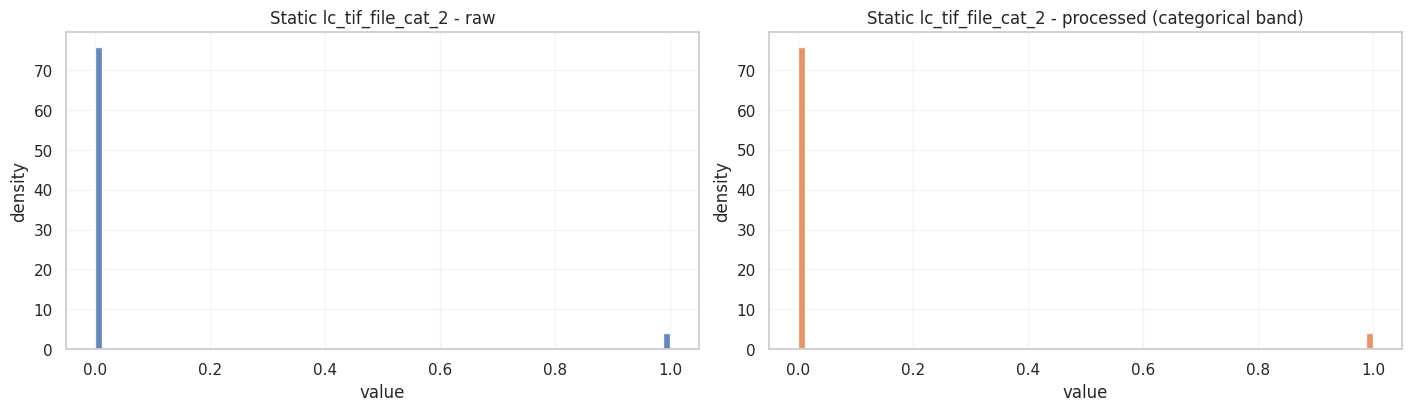

Static channel: lc_tif_file_cat_3
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_3,raw,300000,0.147443,0.354547,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_3,processed (categorical band),300000,0.147443,0.354547,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


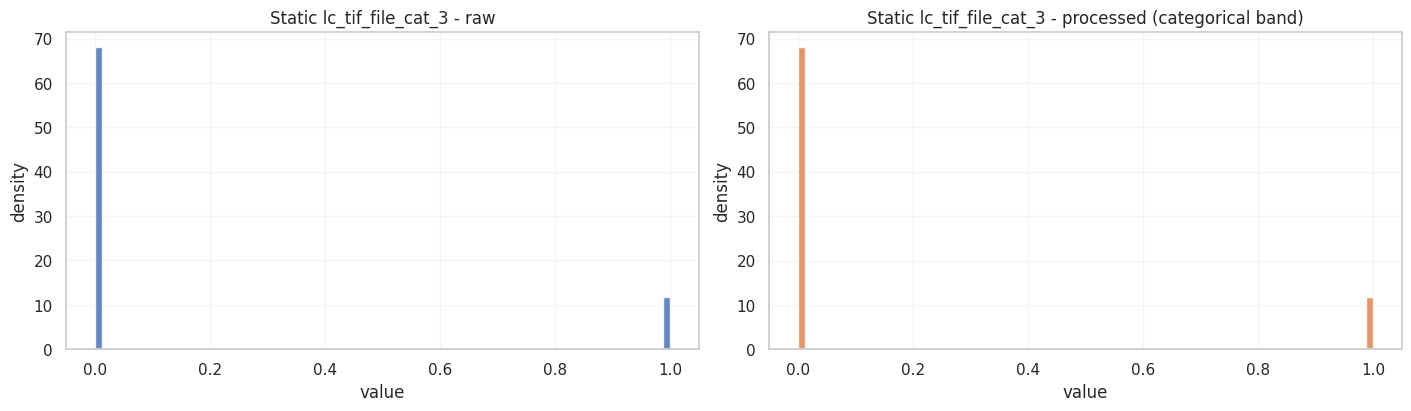

Static channel: lc_tif_file_cat_4
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_4,raw,300000,0.015063,0.121805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_4,processed (categorical band),300000,0.015063,0.121805,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


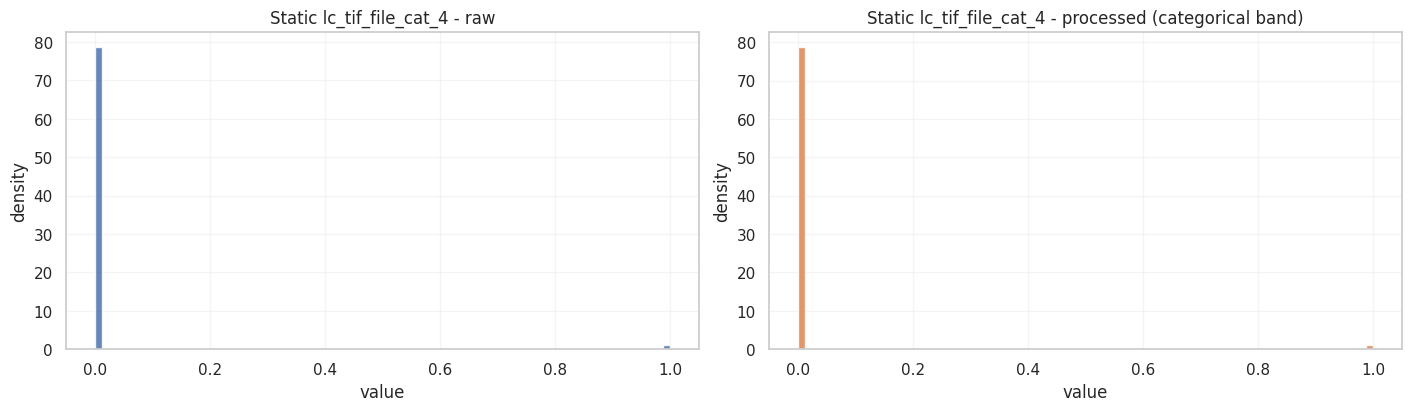

Static channel: lc_tif_file_cat_5
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_5,raw,300000,0.00272,0.052083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_5,processed (categorical band),300000,0.00272,0.052083,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


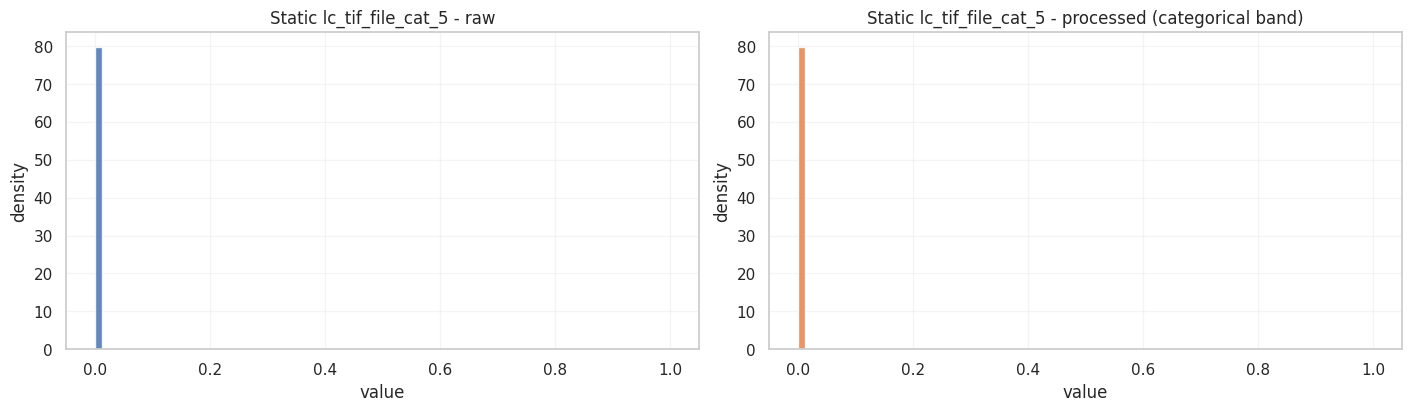

Static channel: lc_tif_file_cat_6
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_6,raw,300000,0.00175,0.041796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_6,processed (categorical band),300000,0.00175,0.041796,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


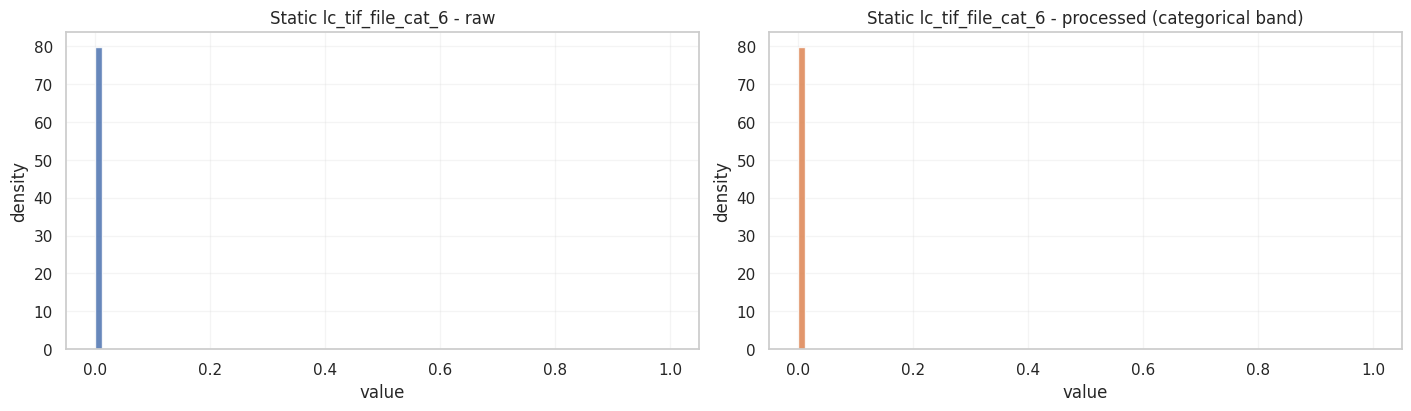

Static channel: lc_tif_file_cat_7
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_7,raw,300000,0.003927,0.06254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_7,processed (categorical band),300000,0.003927,0.06254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


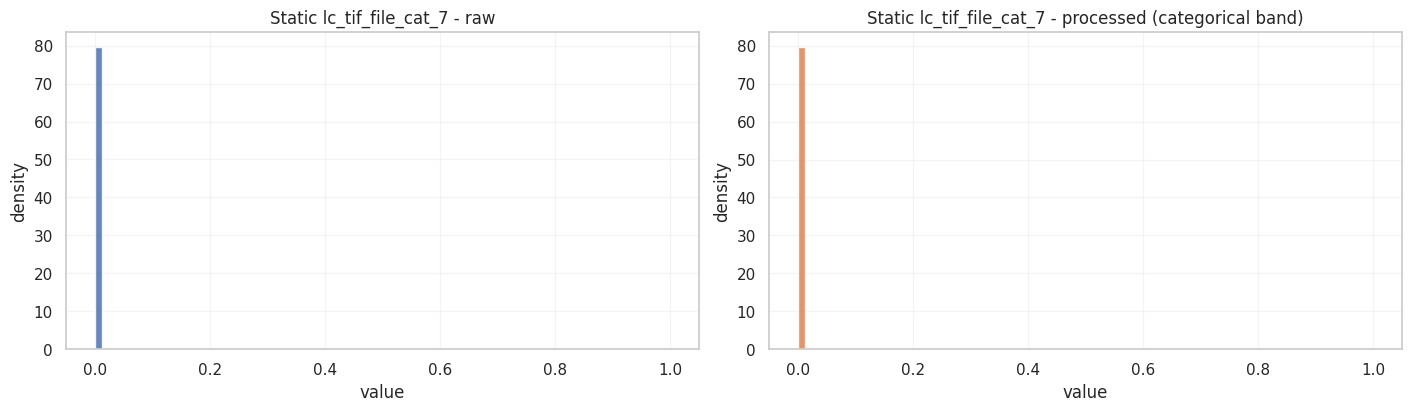

Static channel: lc_tif_file_cat_8
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_8,raw,300000,0.00012,0.010954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_8,processed (categorical band),300000,0.00012,0.010954,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


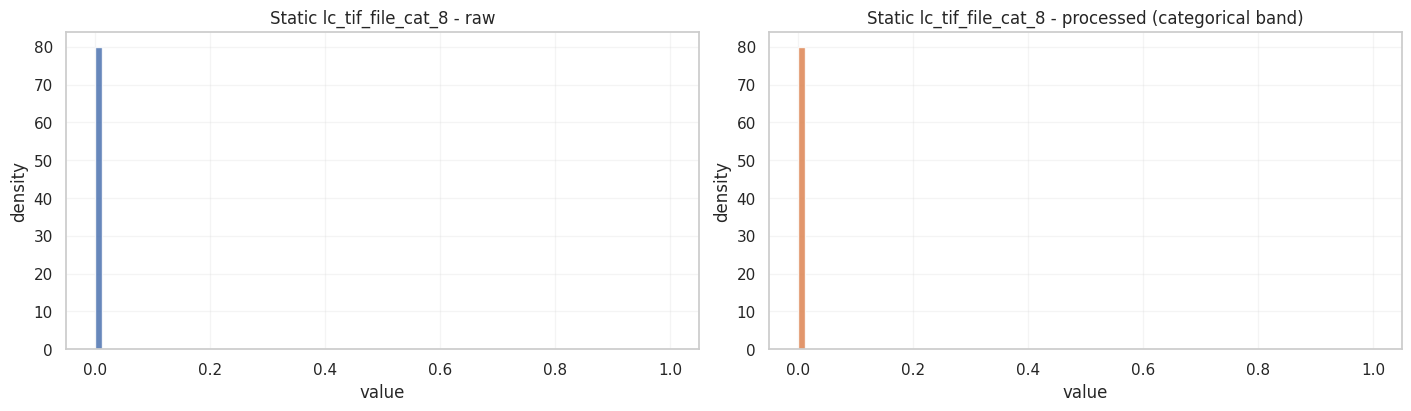

Static channel: lc_tif_file_cat_9
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_9,raw,300000,0.032473,0.177254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_9,processed (categorical band),300000,0.032473,0.177254,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


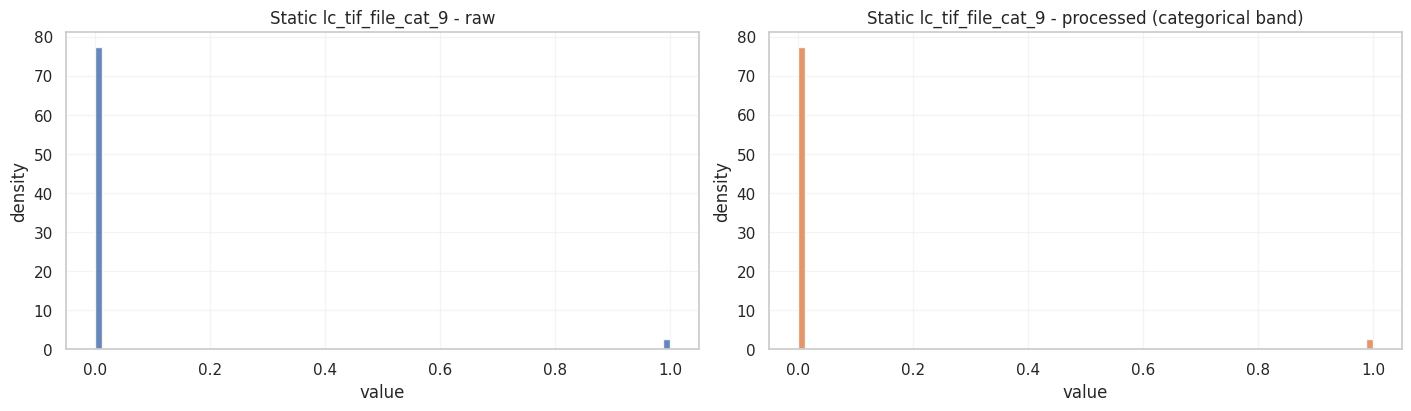

Static channel: lc_tif_file_cat_10
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_10,raw,300000,0.098213,0.297603,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_10,processed (categorical band),300000,0.098213,0.297603,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0


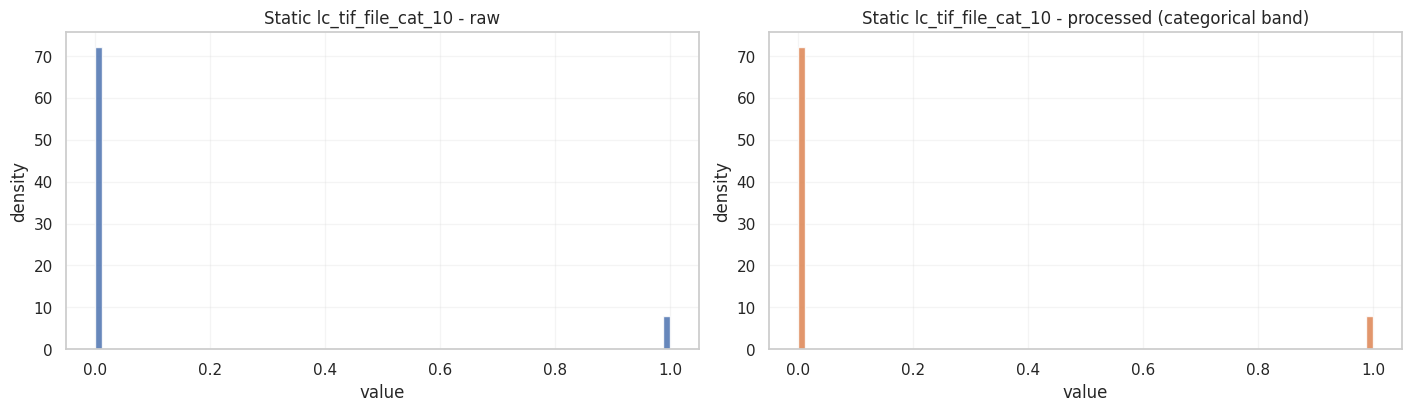

Static channel: lc_tif_file_cat_11
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_11,raw,300000,0.013457,0.11522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_11,processed (categorical band),300000,0.013457,0.11522,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


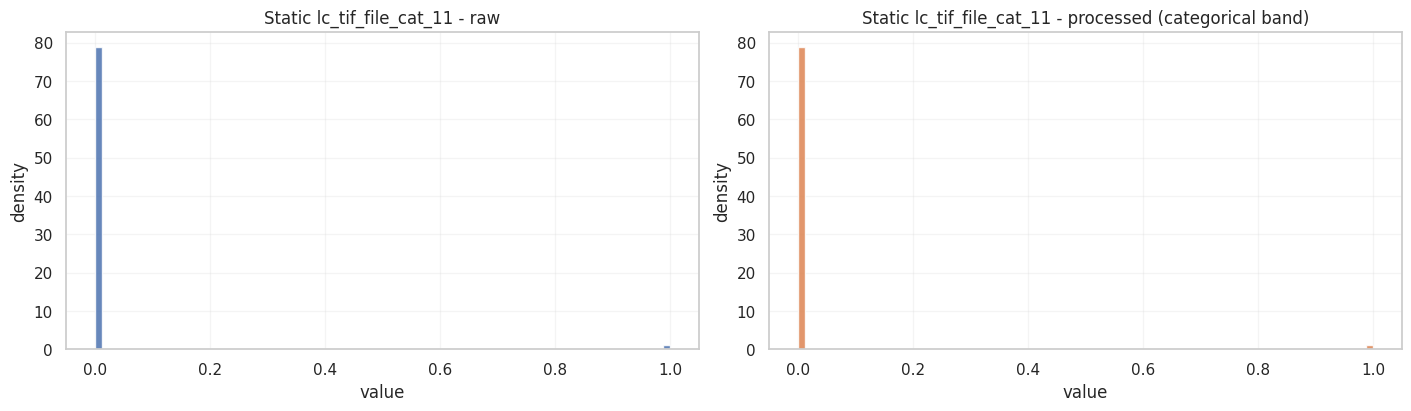

Static channel: lc_tif_file_cat_12
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_12,raw,300000,0.013103,0.113717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_12,processed (categorical band),300000,0.013103,0.113717,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


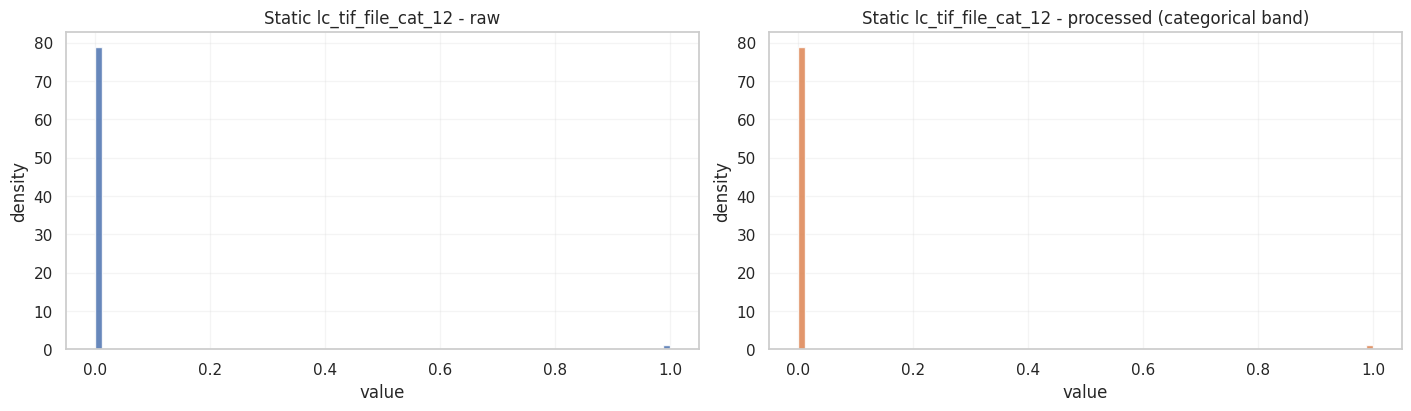

Static channel: lc_tif_file_cat_13
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_13,raw,300000,0.00002,0.004472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_13,processed (categorical band),300000,0.00002,0.004472,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


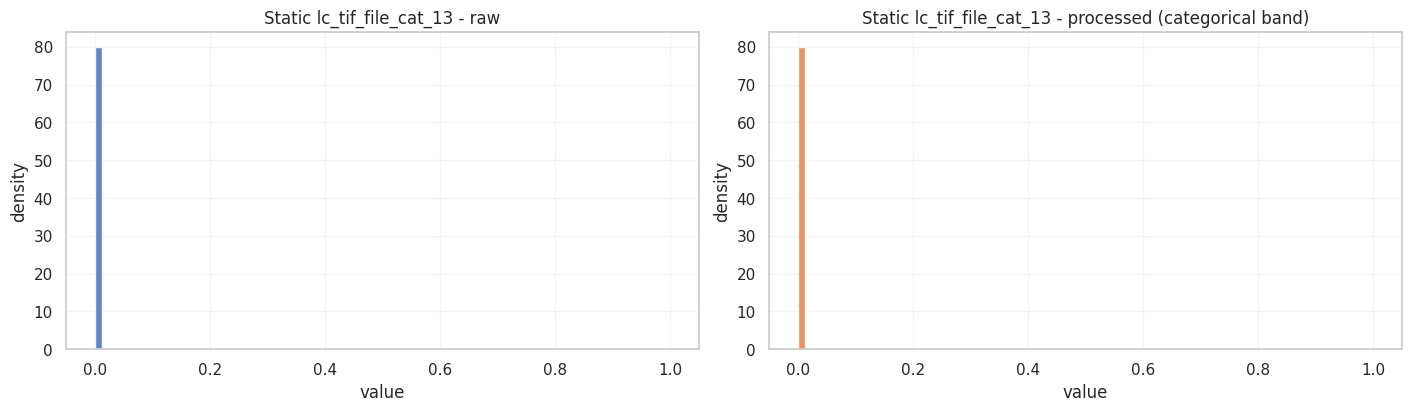

Static channel: lc_tif_file_cat_14
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_14,raw,300000,0.000177,0.01329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_14,processed (categorical band),300000,0.000177,0.01329,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


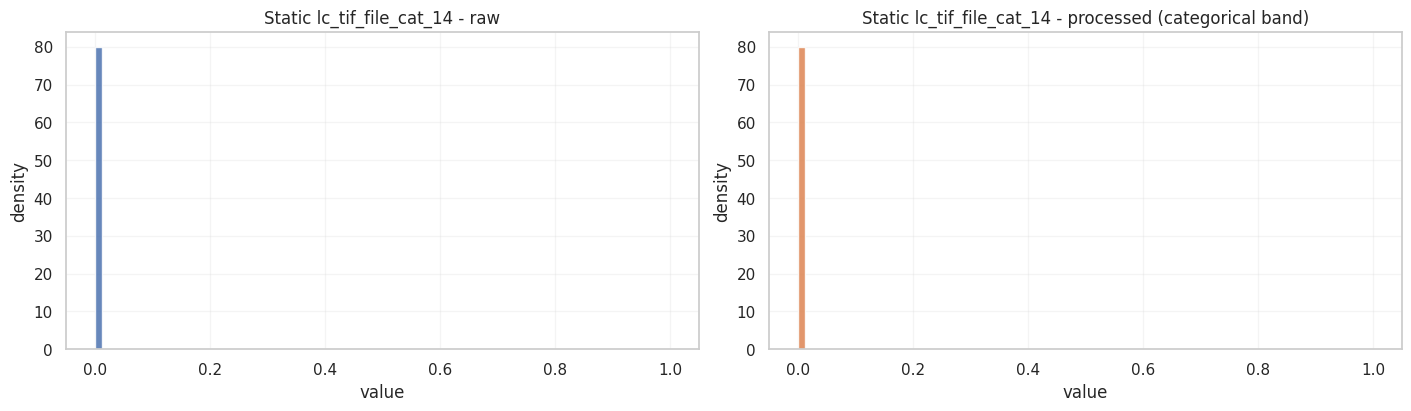

Static channel: lc_tif_file_cat_15
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_15,raw,300000,0.049103,0.216084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_15,processed (categorical band),300000,0.049103,0.216084,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0


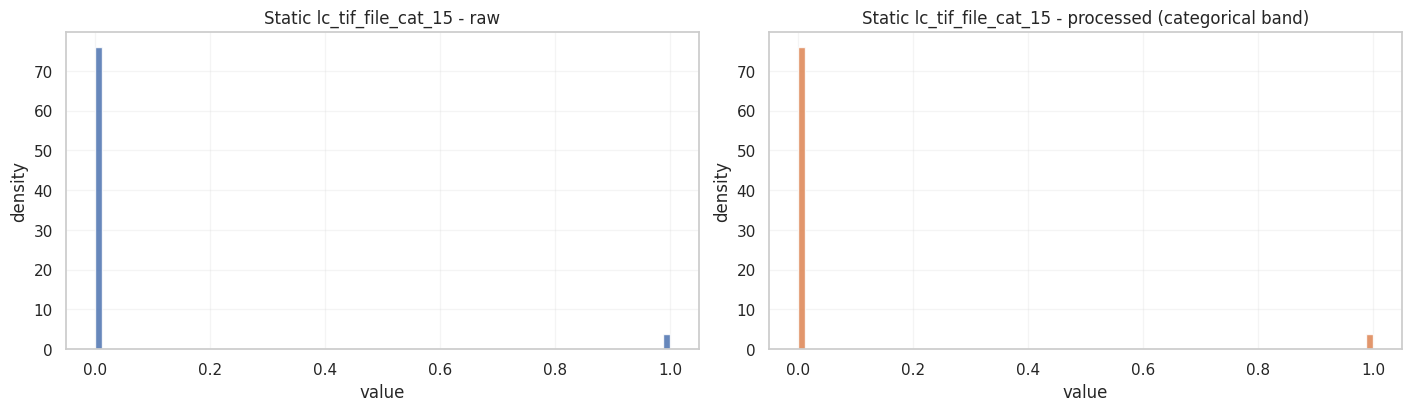

Static channel: lc_tif_file_cat_16
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_16,raw,300000,0.537707,0.498576,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


processed (categorical band) distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lc_tif_file_cat_16,processed (categorical band),300000,0.537707,0.498576,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0


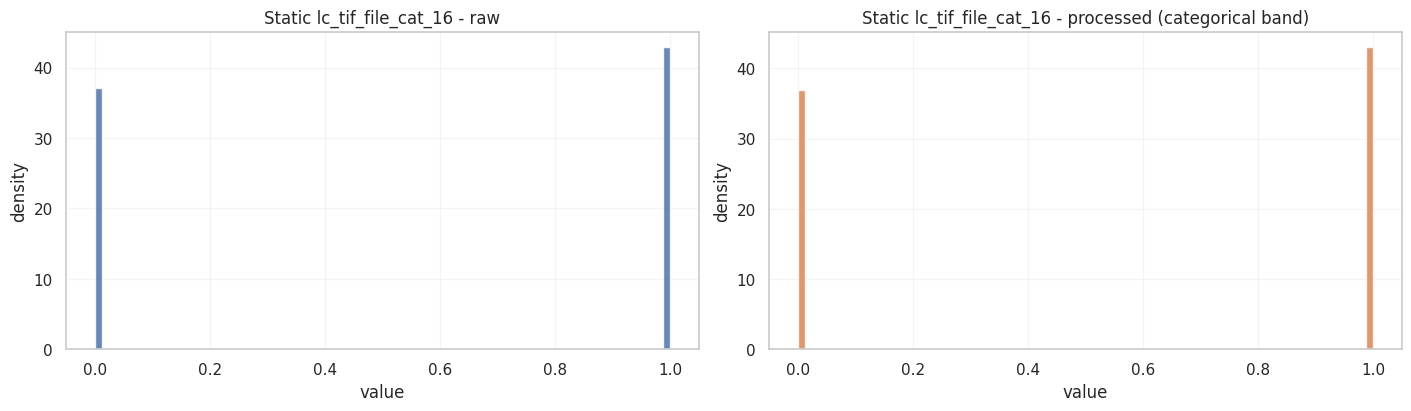

Static channel: lat_tif_file
Raw distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lat_tif_file,raw,300000,2025914.75,388042.90625,1355000.0,1367000.0,1421000.0,1689000.0,2025000.0,2361000.0,2631000.0,2685000.0,2697000.0


normalized distribution table:


,variable,version,count,mean,std,min,p01,p05,p25,p50,p75,p95,p99,max
0,lat_tif_file,normalized,300000,-0.000218,1.000164,-1.729473,-1.698543,-1.559361,-0.868602,-0.002577,0.863448,1.559361,1.698544,1.729473


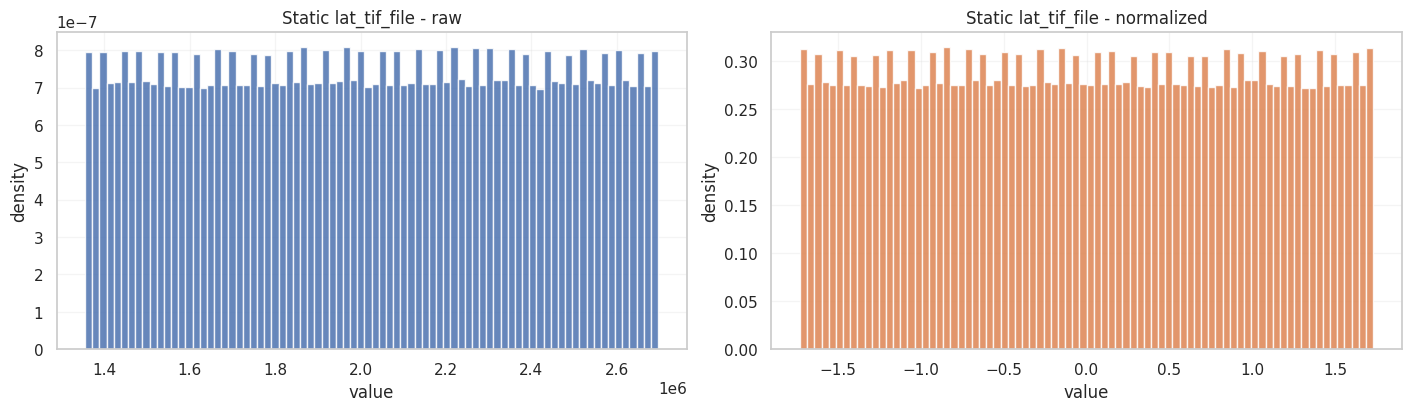

In [36]:
# Static: for EACH channel print 2 tables + 1 horizontal merged figure (raw | processed/normalized)
for key in ds.static_data.keys():
    if key == "dtm_tif_file":
        raw = xr.open_dataset(STATIC_VARS["dtm_tif_file"], engine="rasterio")["band_data"][0].values
        after_name = "normalized"
    elif key == "lat_tif_file":
        raw = xr.open_dataset(STATIC_VARS["lat_tif_file"], engine="rasterio")["band_data"][0].values
        after_name = "normalized"
    elif key.startswith("lc_tif_file_cat_"):
        cat_idx = int(key.split("_cat_")[-1]) - 1
        raw_lc = xr.open_dataset(STATIC_VARS["lc_tif_file"], engine="rasterio")["band_data"].values
        raw = raw_lc[cat_idx]
        after_name = "processed (categorical band)"
    else:
        raw = ds.static_data[key].numpy()
        after_name = "processed"

    proc = ds.static_data[key].numpy()

    print("=" * 90)
    print(f"Static channel: {key}")

    print("Raw distribution table:")
    display(distribution_table_single(raw, variable_name=key, version_name="raw"))

    print(f"{after_name} distribution table:")
    display(distribution_table_single(proc, variable_name=key, version_name=after_name))

    plot_hist_pair_horizontal(
        raw,
        proc,
        variable_name=f"Static {key}",
        raw_label="raw",
        norm_label=after_name,
        bins=80,
    )

## 6) How ERA5 + static (different shapes) are forwarded into LMM

### Key answer
They are **not** forwarded with the same strategy in UNET and context encoder.

### A) UNET path (pixel-space merge)
Used by residual prior path (`AutoencoderKL.nn_lr_and_merge_with_static`, mirrored in `UnetLitModule._merge_lr_and_static`).

1. Low-res ERA5 is upsampled to high-res by fixed factor `x8` using nearest-neighbor style repeat (`repeat_interleave`).
2. Upsampled ERA5 is concatenated with high-res static channels on channel dimension.
3. The merged high-res tensor is fed into UNET.

Core implementation:

```python
low_res = torch.repeat_interleave(low_res, 8, dim=2)
low_res = torch.repeat_interleave(low_res, 8, dim=3)
low_res = torch.cat([low_res, static_data], dim=1)
```

### B) Context encoder path (dual-branch feature fusion)
Used by LMM conditioning (`AFNOConditionerNetCascade`):

- Branch 0 receives static (`z`)
- Branch 1 receives ERA5 low-res (`x`)

Each branch is processed independently:
1. `autoencoder[i].encode(x[i])[0]`
2. `1x1` projection (`proj[i]`)
3. AFNO analysis blocks (`analysis[i]`)

Then branches are fused in `FusionBlock2d`.

So fusion happens in **feature space**, not by direct pixel concat at input.

### Practical takeaway
- **UNET:** explicit spatial alignment first, then concat.
- **Conditioner:** separate encoders then feature fusion.
- Therefore, **same inputs, different integration strategy**.

## 7) How data normalization is done (methods, formulas, config knobs)

### 7.1 Static inputs (high-res)
In `DownscalingDataset.__init__`, static rasters are loaded and (for non-landcover fields) normalized with:

```python
(tensor - tensor.mean()) / (tensor.std() + 1e-10)
```

Method name in code: `DownscalingDataset.normalize`.

Applied to:
- `dtm_tif_file`
- `lat_tif_file`

Land-cover (`lc_tif_file`) is expanded to category channels (`lc_tif_file_cat_*`) and used as categorical bands (not z-scored by this method).

### 7.2 ERA5 dynamic inputs (low-res)
In this dataset loader (`DownscalingDataset`), ERA5 channels are stacked as float tensors.

Explicit transform seen in code:
- `SST` NaNs are replaced with `-10` via `torch.nan_to_num`.

No explicit per-channel z-score call is applied here inside `DownscalingDataset` for ERA5.

### 7.3 Project normalization stats utility
The repository includes shared normalization stats (`normalization_data.pkl`) and helpers in `utils/temperature_normalization.py`:

- `load_norm_stats(...)`
- `normalize_temperature(...)`
- `denormalize_temperature(...)`

Formula used there:

```python
(field - mean) / std
```

Stats are keyed by source (`ERA5`, `CMCC`) and variable.

### 7.4 Configs/knobs that matter
Primary config locations:
- `configs/data/downscaling.yaml`
  - `target_vars.low_res`
  - `target_vars.high_res`
  - `static_vars.*`
  - `nn_lowres`
- `configs/model/lmm.yaml`
  - `context_encoder.input_size_ratios`
  - conditioner branch definitions

Interpretation:
- `nn_lowres: false` (LMM/LDM) keeps low-res and static as separate tensors from dataset output.
- UNET and conditioner then combine them with different strategies (Section 6 above).

### 7.5 Pipeline truth table (quick reference)
| Tensor family | Load-time transform in `DownscalingDataset` | Normalization method | Main consumer path |
|---|---|---|---|
| ERA5 low-res dynamic channels | stack channels, cast `float32`; `SST` NaN -> `-10` | no explicit per-channel z-score in this class | UNET merge path + conditioner low-res branch |
| Static DTM / LAT | raster load, then z-score | `DownscalingDataset.normalize` | UNET merge path + conditioner static branch |
| Static land-cover channels | expand category bands (`lc_tif_file_cat_*`) | categorical bands (not z-scored here) | UNET merge path + conditioner static branch |

Note: utilities based on `normalization_data.pkl` are available and used in analysis/inference scripts; this notebook uses them explicitly when plotting normalized ERA5 distributions.